In [ ]:
# Install required packages
try:
    import tensorflow as tf
    print(f"TensorFlow {tf.__version__} is already installed")
except ImportError:
    print("Installing TensorFlow...")
    %pip install tensorflow
    import tensorflow as tf
    print(f"TensorFlow {tf.__version__} installed successfully")

try:
    from sklearn.metrics import confusion_matrix
    print("scikit-learn is already installed")
except ImportError:
    print("Installing scikit-learn...")
    %pip install scikit-learn
    print("scikit-learn installed successfully")


Installing TensorFlow...
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 MB 27.0 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 28.8 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 18.0 MB/s  0:00:00
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.6 MB/s  0:00:00
Using cached urllib3-2.5.0-py3-none-any.whl (129 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 36.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 25.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 24.9 MB/s  0:00:00
   ━━━━━━━━━━━━━

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

import random

# set reproducibility seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

# =========================================================
# 1. Download Kaggle dataset
# =========================================================
dataset_path = kagglehub.dataset_download("ashwingupta3012/male-and-female-faces-dataset")

# =========================================================
# 2. Correct path to actual image folders
# =========================================================
images_path = os.path.join(dataset_path, "Male and Female face dataset")
print("Image folders:", os.listdir(images_path))  # Should show ['Male', 'Female']

# =========================================================
# 3. Set parameters (optimized for faster training)
# =========================================================
image_width  = 128  # Reduced from 150 for faster training
image_height = 128  # Reduced from 150 for faster training
batch_size   = 64   # Increased from 32 for faster training (more samples per batch)

# =========================================================
# 4. Create training and validation datasets
# =========================================================
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    images_path,
    validation_split=0.2,
    subset='training',
    seed=1,
    shuffle=True,
    image_size=(image_width, image_height),
    batch_size=batch_size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    images_path,
    validation_split=0.2,
    subset='validation',
    seed=1,
    shuffle=False,  # False for validation - better for reproducibility
    image_size=(image_width, image_height),
    batch_size=batch_size
)

class_labels = train_data.class_names
print("Classes:", train_data.class_names)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Image dimensions already set above (128x128, batch_size=64)
# No need to redefine - keeping for reference

# scale images
# referenced from in class coding
def scale(image, label):
  return image / 255.0, label

train_data = train_data.map(scale)
test_data = test_data.map(scale)

# Optimize data loading for faster training
train_data = train_data.cache().prefetch(tf.data.AUTOTUNE)
test_data = test_data.cache().prefetch(tf.data.AUTOTUNE)
print("Data loading optimized with caching and prefetching")



In [ ]:
# =========================================================
# 2. Build a CNN model with ≥3 convolutional layers
# =========================================================
# Architecture:
#   conv1 → pool1 → conv2 → pool2 → conv3 → pool3 → flatten → dense → dropout → output
# =========================================================

model = Sequential([
    # --- Convolutional block 1 ---
    Conv2D(32, (3,3), activation='relu',
           input_shape=(image_width, image_height, 3),
           name="conv1"),
    MaxPooling2D(2,2, name="pool1"),

    # --- Convolutional block 2 ---
    Conv2D(64, (3,3), activation='relu', name="conv2"),
    MaxPooling2D(2,2, name="pool2"),

    # --- Convolutional block 3 ---
    Conv2D(128, (3,3), activation='relu', name="conv3"),
    MaxPooling2D(2,2, name="pool3"),

    # --- Dense layers ---
    Flatten(name="flatten"),
    Dense(128, activation='relu', name="dense1"),
    Dropout(0.3, name="dropout"),
    Dense(1, activation='sigmoid', name="output")  # Binary classification: Male vs Female
])

# =========================================================
# Compile the model
# =========================================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print the model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================================================
# 3. Train the model
#    (you can adjust epochs if it’s too slow)
# =========================================================

EPOCHS = 3  # Reduced for faster training - can increase if needed

history = model.fit(
    train_data,
    validation_data=test_data,  # Using test data for evaluation during training
    epochs=EPOCHS,
    verbose=1
)


Epoch 1/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.6282 - loss: 0.6248 - val_accuracy: 0.8172 - val_loss: 0.4298
Epoch 2/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.8385 - loss: 0.3550 - val_accuracy: 0.8772 - val_loss: 0.2846
Epoch 3/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.9350 - loss: 0.1689 - val_accuracy: 0.9640 - val_loss: 0.1416
Epoch 4/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9815 - loss: 0.0575 - val_accuracy: 0.9788 - val_loss: 0.0984
Epoch 5/5
136/136 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9869 - loss: 0.0404 - val_accuracy: 0.9852 - val_loss: 0.0888


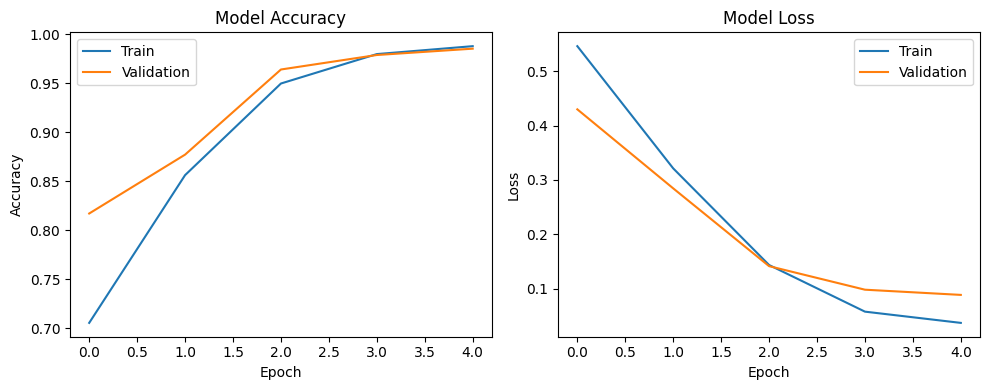

In [ ]:
# =========================================================
# 4. Plot training history (accuracy & loss)
# =========================================================

plt.figure(figsize=(10,4))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')  # Changed label to Test
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')  # Changed label to Test
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

34/34 ━━━━━━━━━━━━━━━━━━━━ 32s 929ms/step


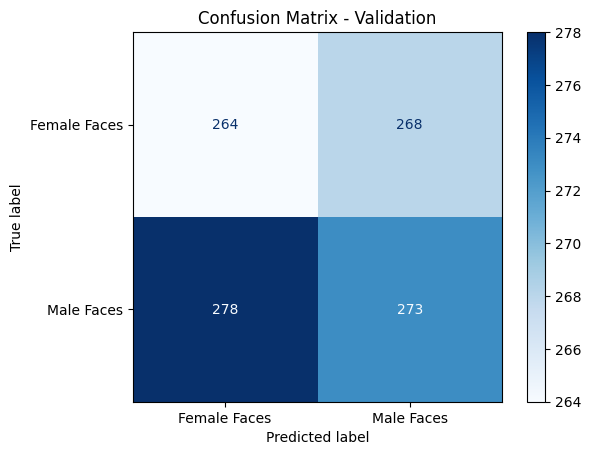


Classification Report:

              precision    recall  f1-score   support

Female Faces       0.49      0.50      0.49       532
  Male Faces       0.50      0.50      0.50       551

    accuracy                           0.50      1083
   macro avg       0.50      0.50      0.50      1083
weighted avg       0.50      0.50      0.50      1083



In [ ]:
# ----------------------------
# 6. Confusion matrix
# ----------------------------
# Extract true labels and predictions correctly
y_true_list = []
y_pred_list = []

# Iterate through test data to get predictions
for images, labels in test_data:
    y_true_list.append(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_list.append((preds > 0.5).astype(int).flatten())

# Concatenate all batches
y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Test Data")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))
print(f"\nTest Accuracy: {(y_true == y_pred).mean():.4f}")

In [ ]:
# Convert test dataset to numpy arrays
test_images_list = []
y_true_list = []

for images, labels in test_data:
    test_images_list.append(images.numpy())
    y_true_list.append(labels.numpy())

test_images = np.concatenate(test_images_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)

# y_pred already computed from previous cell
# If not, compute it:
if 'y_pred' not in locals():
    y_pred_list = []
    for images, _ in test_data:
        preds = model.predict(images, verbose=0)
        y_pred_list.append((preds > 0.5).astype(int).flatten())
    y_pred = np.concatenate(y_pred_list, axis=0)

# Indices
correct_idx = np.where(y_pred == y_true)[0]
wrong_idx   = np.where(y_pred != y_true)[0]

print(f"Total test images: {len(y_true)}")
print(f"Correct predictions: {len(correct_idx)}")
print(f"Incorrect predictions: {len(wrong_idx)}")

# Function to plot examples
def plot_examples(images, indices, title, n=6):
    n = min(n, len(indices))
    if n == 0:
        print(f"No images available for {title}")
        return

    plt.figure(figsize=(12, 6))
    for i in range(n):
        idx = indices[i]
        img_array = images[idx]

        plt.subplot(2, 3, i+1)
        plt.imshow(img_array)
        true_label = class_labels[y_true[idx]]
        pred_label = class_labels[y_pred[idx]]
        color = "green" if true_label == pred_label else "red"
        plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Plot some correct predictions
if len(correct_idx) > 0:
    plot_examples(test_images, correct_idx[:6], "Correct Predictions")
else:
    print("No correct predictions to display")

# Plot some incorrect predictions
if len(wrong_idx) > 0:
    plot_examples(test_images, wrong_idx[:6], "Incorrect Predictions (Investigate for bias!)")
else:
    print("No incorrect predictions - perfect model!")


NameError: name 'idx' is not defined

In [ ]:
# =========================================================
# 8. Highlight two interesting filters (part c)
#    We'll visualize filters (kernels) from the first conv layer.
# =========================================================

first_conv = model.get_layer("conv1")
filters, biases = first_conv.get_weights()  # filters shape: (3, 3, 3, num_filters)

print("conv1 filters shape:", filters.shape)

# Normalize filter values for visualization
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)

num_filters_to_show = 4  # you can increase if you want
plt.figure(figsize=(8, 4))
for i in range(num_filters_to_show):
    f = filters_norm[:, :, :, i]   # shape: (3, 3, 3)
    # Show as RGB image
    plt.subplot(1, num_filters_to_show, i+1)
    plt.imshow(f)
    plt.axis('off')
plt.suptitle("Example filters from 'conv1' (part c)")
plt.tight_layout()
plt.show()
